In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from sklearn.pipeline import make_pipeline
from imblearn.over_sampling import SMOTE

In [2]:
df = pd.read_csv('Dataset/1.creditcard.csv')
print(df.info())
print(df.describe())

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

In [3]:
scaler = StandardScaler()
X = df.drop('Class', axis=1)
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)  # 按y的类别比例进行分层抽样

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [4]:
# 过采样使少数类的样本数量增加到和多数类一样多
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)
print(pd.Series(y_train_smote).value_counts())

Class
0    227451
1    227451
Name: count, dtype: int64


In [5]:
model = LogisticRegression(random_state=42, max_iter=1000)
model.fit(X_train_smote, y_train_smote)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [6]:
y_pred = model.predict(X_test_scaled)
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]  # 返回每个样本属于各个类别的概率,是1的概率

conf_matrix = confusion_matrix(y_test, y_pred)
print('Confusion Matrix:\n', conf_matrix)

print('Classification Report:\n', classification_report(y_test, y_pred))

fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)
print('AUC:', roc_auc)

Confusion Matrix:
 [[55397  1467]
 [    8    90]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.97      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.99     56962

AUC: 0.9708434302252134


#### 二分类混淆矩阵

| 真实 \ 预测 | 预测为 0 | 预测为 1 |
| :---: | :---: | :---: |
| **真实为 0** | TN（真负例） | FP（假正例） |
| **真实为 1** | FN（假负例） | TP（真正例） |

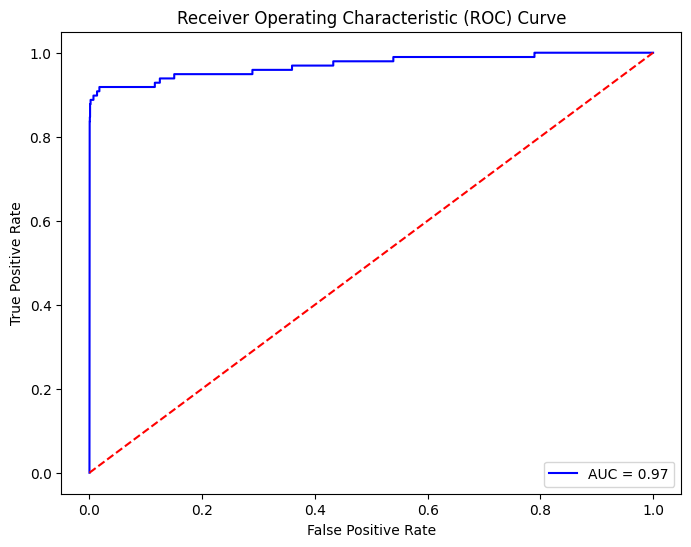

In [7]:
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='b', label=f'AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], color='r', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()

In [8]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [0.1, 1, 10, 100],
    'solver': ['lbfgs', 'liblinear']
}

grid = GridSearchCV(LogisticRegression(random_state=42, max_iter=1000), param_grid, cv=5, scoring='roc_auc')

grid.fit(X_train_smote, y_train_smote)

print(f'Best Parameters: {grid.best_params_}')

Best Parameters: {'C': 100, 'solver': 'liblinear'}


### `C` 的详细说明

- `C` 是**正则化惩罚的倒数**（`C = 1 / α`，`α` 是正则化强度）
- **C 大**（如 100）：正则化弱，模型更拟合数据，容易过拟合
- **C 小**（如 0.1）：正则化强，模型更平滑，容易欠拟合
- 候选值通常按对数尺度取：`[0.01, 0.1, 1, 10, 100]`

### `solver` 的详细说明

| solver | 特点 | 适用场景 |
|--------|------|---------|
| `'lbfgs'` | 拟牛顿法，速度快，支持 L2 正则化 | 默认推荐，中小数据集（sklearn 默认） |
| `'liblinear'` | 坐标下降法，支持 L1 和 L2 正则化 | 小数据集，需要 L1 正则化时用 |
| `'saga'` | 支持 L1/L2/ElasticNet，适合大数据 | 大数据集，需要弹性网时用 |

### `lbfgs` 和 `liblinear` 对比

| 对比项 | `lbfgs` | `liblinear` |
|--------|---------|-------------|
| L1 正则化 | ❌ 不支持 | ✅ 支持 |
| L2 正则化 | ✅ 支持 | ✅ 支持 |
| 大数据 | ✅ 适合 | ❌ 慢 |
| 默认选择 | ✅ sklearn 默认 | ❌ 需手动指定 |

Confusion Matrix (Optimized):
 [[55403  1461]
 [    8    90]]
Classification Report (Optimized):
               precision    recall  f1-score   support

           0       1.00      0.97      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.99     56962

AUC (Optimized): 0.9709415878056343


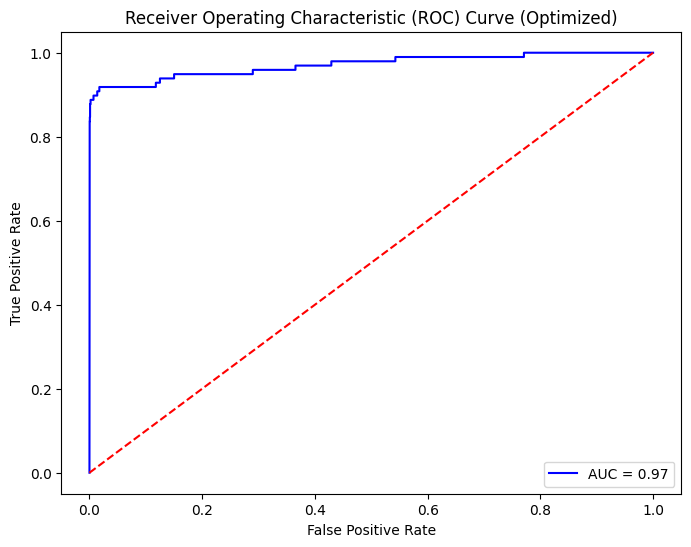

In [10]:
best_model = grid.best_estimator_
best_model.fit(X_train_smote, y_train_smote)

y_pred_best = best_model.predict(X_test_scaled)
y_pred_proba_best = best_model.predict_proba(X_test_scaled)[:, 1]

conf_matrix_best = confusion_matrix(y_test, y_pred_best)
print('Confusion Matrix (Optimized):\n', conf_matrix_best)

print('Classification Report (Optimized):\n', classification_report(y_test, y_pred_best))

fpr_best, tpr_best, thresholds_best = roc_curve(y_test, y_pred_proba_best)
roc_auc_best = auc(fpr_best, tpr_best)
print('AUC (Optimized):', roc_auc_best)

plt.figure(figsize=(8, 6))
plt.plot(fpr_best, tpr_best, color='b', label=f'AUC = {roc_auc_best:.2f}')
plt.plot([0, 1], [0, 1], color='r', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve (Optimized)')
plt.legend(loc='lower right')
plt.show()

适用场景
1. 特征与目标之间存在线性关系：逻辑回归在特征与目标变量存在线性关系时表现出色，如广告点击率预测、简单的二分类问题。

2. 数据集较小且维度适中：当数据集规模适中且特征数目适当时，逻辑回归能够快速构建有效的分类模型。

3. 可解释性要求高：在需要对特征与目标变量之间关系进行清晰解释的场合，逻辑回归的简单性和可解释性是其优势。

4. 需要概率输出：逻辑回归直接提供事件发生的概率，适合需要概率预测的应用，如医学诊断、信用评分等。

替代选择
1. 非线性数据：当数据的模式复杂且呈现非线性时，使用决策树、随机森林或神经网络更为适合。

2. 大规模数据：在大规模数据集上，逻辑回归可能性能有限，可以考虑分布式算法或梯度提升方法（如XGBoost、LightGBM）。

3. 处理高维数据：对于高维数据，可以考虑支持向量机、朴素贝叶斯等方法，它们能够有效处理大量特征。

4. 应对类别不平衡：当类别极度不平衡时，可以选择基于采样方法的集成模型（如平衡随机森林），或者专门设计的算法（如异常检测模型）。